# Train LayoutLMv3 cho CV parsing + Active Learning

## Chiến lược dùng GPU (Colab free)
Notebook chia **2 phase** để tiết kiệm quota T4:

- **PHASE A — CPU**: OCR (PaddleOCR) + match box Label Studio + chọn pool active learning → lưu data đã chuẩn bị ra Drive (`train_examples.json`, `al_pool_ocr.json`). **Không cần GPU.**
- **PHASE B — GPU T4**: chỉ nạp data đã chuẩn bị → **train LayoutLMv3** + active learning inference. Dùng T4 ngắn gọn.

Cách chạy:
1. Đặt runtime ở **CPU**, chạy **SETUP** → **PHASE A**.
2. Đổi **Runtime → Change runtime type → T4 GPU**, **chạy lại SETUP**, rồi chạy **PHASE B**.

> Phần *suggestion* (crawl JD + SVM/Random Forest + template) sẽ làm ở một notebook riêng.

## Chuẩn bị dữ liệu trên Google Drive
Trong thư mục `MyDrive/DATN/` đặt:
- **folder `dataset_new`** — toàn bộ ảnh CV (đã/để label). Upload thẳng folder, **không cần nén**.
- `project-4-at-2026-06-09-14-29-48bf9095.json` — file export Label Studio.


## ⚙️ SETUP  (chạy ở CẢ 2 phase — sau khi đổi runtime nhớ chạy lại 2 cell SETUP)


In [ ]:
# === SETUP 1/2: import nhẹ + mount Drive + cấu hình đường dẫn ===
import os, re, json, random, collections
import numpy as np
from PIL import Image
import cv2
from tqdm.auto import tqdm
from google.colab import drive

drive.mount('/content/drive')

# ===== CHỈNH CHO ĐÚNG ĐƯỜNG DẪN TRÊN DRIVE CỦA BẠN =====
DRIVE_ROOT = "/content/drive/MyDrive/DATN"
IMAGES_DIR = f"{DRIVE_ROOT}/dataset/dataset_new"   # folder ảnh đã upload sẵn (KHÔNG nén)

# Bạn có thể liệt kê nhiều file export JSON ở đây, script sẽ gộp tất cả lại
LS_EXPORTS  = [
    f"{DRIVE_ROOT}/dataset/project-4-at-2026-06-09-14-29-48bf9095.json",
    #f"{DRIVE_ROOT}/dataset/project-5-at-2026-06-11-05-28-d1d40426.json" # Thêm file export chứa 60 CV mới tại đây
]

OUTPUT_DIR = f"{DRIVE_ROOT}/layoutlmv3_out"
# ========================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Data PHASE A ghi -> PHASE B đọc
TRAIN_CACHE = f"{OUTPUT_DIR}/train_examples.json"
POOL_CACHE  = f"{OUTPUT_DIR}/al_pool_ocr.json"

assert os.path.isdir(IMAGES_DIR), f"Không thấy thư mục ảnh: {IMAGES_DIR}"
print("IMAGES_DIR =", IMAGES_DIR, "| OUTPUT_DIR =", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IMAGES_DIR = /content/drive/MyDrive/DATN/dataset/dataset_new | OUTPUT_DIR = /content/drive/MyDrive/DATN/layoutlmv3_out


In [ ]:
# === SETUP 2/2: nhãn (BIO) + helper dùng chung 2 phase ===
ENTITIES = ["NAME", "EMAIL", "PHONE", "SUMMARY", "EDUCATION", "EXPERIENCE", "SKILL",
            "SOFT_SKILL", "JOB_TITLE", "COMPANY", "DATE", "LOCATION", "CANDIDATE_LOCATION",
            "CERTIFICATION", "LANGUAGE", "PROJECT", "GPA", "LINK"]
labels = ["O"]
for e in ENTITIES:
    labels += [f"B-{e}", f"I-{e}"]
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
num_labels = len(labels)

def normalize_box(box, W, H):
    def n(v, m): return min(1000, max(0, int(round(1000.0 * v / max(m, 1)))))
    return [n(box[0], W), n(box[1], H), n(box[2], W), n(box[3], H)]

print(num_labels, "lớp")


37 lớp


---
## 🅰️ PHASE A — CPU: OCR + chuẩn bị data
Đặt **Runtime = CPU** (không tốn quota GPU). Chạy hết PHASE A rồi mới đổi sang T4.


In [ ]:
# === PHASE A: cài PaddleOCR bản CPU (nhẹ, không cần GPU) ===
!pip -q install paddlepaddle
!pip -q install "paddleocr>=2.7,<3.0"
!pip -q install -U "Pillow>=10.0" opencv-python-headless
print("Cài xong PHASE A. Nếu import PaddleOCR ở cell sau lỗi numpy/opencv -> "
      "Runtime > Restart session rồi chạy lại từ SETUP.")


Cài xong PHASE A. Nếu import PaddleOCR ở cell sau lỗi numpy/opencv -> Runtime > Restart session rồi chạy lại từ SETUP.


In [ ]:
# === PHASE A: parse Label Studio export -> {filename: [region(%)]} ===
def parse_label_studio(paths):
    out = {}
    for path in paths:
        if not os.path.exists(path):
            print(f"Cảnh báo: Không tìm thấy file {path}, có thể bạn chưa upload lên Drive.")
            continue
        data = json.load(open(path, encoding="utf-8"))
        for task in data:
            img = task.get("data", {}).get("image", "")
            m = re.search(r"[?&]d=([^&]+)", img)
            fname = os.path.basename(m.group(1) if m else img)
            ann = next((a for a in task.get("annotations", []) if not a.get("was_cancelled")), None)
            if not ann:
                continue
            regions = []
            for r in ann.get("result", []):
                if r.get("type") != "rectanglelabels":
                    continue
                v = r["value"]
                lbls = v.get("rectanglelabels") or []
                if not lbls:
                    continue
                regions.append({"label": lbls[0], "x": v["x"], "y": v["y"],
                                "w": v["width"], "h": v["height"]})
            if regions:
                out[fname] = regions
    return out

ls_regions = parse_label_studio(LS_EXPORTS)
print("Số CV có nhãn (tổng hợp từ nhiều file):", len(ls_regions))
seen = collections.Counter(r["label"] for rs in ls_regions.values() for r in rs)
unknown = set(seen) - set(ENTITIES)
print("Số box theo nhãn:", dict(seen))
assert not unknown, f"Có nhãn lạ chưa khai báo trong ENTITIES: {unknown}"

Số CV có nhãn (tổng hợp từ nhiều file): 162
Số box theo nhãn: {'NAME': 158, 'EMAIL': 137, 'PHONE': 153, 'SUMMARY': 134, 'EDUCATION': 271, 'EXPERIENCE': 495, 'JOB_TITLE': 506, 'SKILL': 1776, 'COMPANY': 344, 'DATE': 505, 'LOCATION': 305, 'CANDIDATE_LOCATION': 119, 'PROJECT': 43, 'LINK': 130, 'SOFT_SKILL': 340, 'GPA': 18, 'CERTIFICATION': 111, 'LANGUAGE': 52}


In [ ]:
# === PHASE A: OCR (PaddleOCR-CPU) + match box -> nhãn token (BIO), lưu ra Drive ===
from paddleocr import PaddleOCR
ocr_engine = PaddleOCR(use_angle_cls=True, lang='en', show_log=False, use_gpu=False)

def quad_to_aabb(quad):
    xs = [float(p[0]) for p in quad]; ys = [float(p[1]) for p in quad]
    return [min(xs), min(ys), max(xs), max(ys)]

def split_line_to_words(text, box):
    # Chia box dòng thành box từng từ theo tỉ lệ số ký tự (xấp xỉ)
    x1, y1, x2, y2 = box
    words = text.split()
    if not words:
        return []
    total = max(sum(len(w) for w in words) + max(len(words) - 1, 0), 1)
    out, cur, span = [], x1, (x2 - x1)
    for w in words:
        wx2 = cur + (len(w) / total) * span
        out.append((w, [cur, y1, wx2, y2]))
        cur = wx2 + (1.0 / total) * span  # chừa 1 ký tự khoảng trắng
    return out

def run_ocr_words(img_path):
    res = ocr_engine.ocr(img_path, cls=True)
    lines = res[0] if (res and res[0]) else []
    words = []
    for item in lines:
        quad, (text, conf) = item[0], item[1]
        words.extend(split_line_to_words(text, quad_to_aabb(quad)))
    return words  # list (word, [x1,y1,x2,y2] pixel)

def pct_to_px(r, W, H):
    x1, y1 = r["x"] / 100.0 * W, r["y"] / 100.0 * H
    return [x1, y1, x1 + r["w"] / 100.0 * W, y1 + r["h"] / 100.0 * H]

def overlap_area(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    return 0.0 if (ix2 <= ix1 or iy2 <= iy1) else (ix2 - ix1) * (iy2 - iy1)

def match_label(wbox, regions_px):
    cx, cy = (wbox[0] + wbox[2]) / 2, (wbox[1] + wbox[3]) / 2
    inside = [r for r in regions_px if r[2][0] <= cx <= r[2][2] and r[2][1] <= cy <= r[2][3]]
    if inside:
        best = max(inside, key=lambda r: overlap_area(wbox, r[2]))
        return best[0], best[1]
    best, bestov = None, 0.0
    for r in regions_px:
        ov = overlap_area(wbox, r[2])
        if ov > bestov:
            bestov, best = ov, r
    wa = (wbox[2] - wbox[0]) * (wbox[3] - wbox[1])
    if best and wa > 0 and bestov / wa > 0.5:   # fallback: phủ > 50% diện tích từ
        return best[0], best[1]
    return None, "O"

def build_example(fname, regions):
    path = os.path.join(IMAGES_DIR, fname)
    if not os.path.exists(path):
        return None
    img = Image.open(path).convert("RGB"); W, H = img.size
    wb = run_ocr_words(path)
    if not wb:
        return None
    regions_px = [(i, r["label"], pct_to_px(r, W, H)) for i, r in enumerate(regions)]
    words, boxes, tags, started = [], [], [], set()
    for w, wbox in wb:
        ridx, lab = match_label(wbox, regions_px)
        if ridx is None or lab == "O":
            tag = "O"
        elif ridx in started:
            tag = f"I-{lab}"
        else:
            tag = f"B-{lab}"; started.add(ridx)
        words.append(w); boxes.append(normalize_box(wbox, W, H)); tags.append(tag)
    # Lưu image_file (tương đối) để PHASE B ghép lại path từ IMAGES_DIR
    return {"image_file": fname, "words": words, "boxes": boxes,
            "ner_tags": [label2id[t] for t in tags]}

# === Cache TĂNG DẦN: giữ CV đã OCR, chỉ OCR THÊM các CV mới (cho vòng retrain) ===
# Lưu ý: nếu bạn SỬA nhãn của CV đã có sẵn (không phải thêm CV mới), hãy XOÁ
# train_examples.json để OCR + match lại từ đầu, vì cache không tự bắt thay đổi đó.
examples = json.load(open(TRAIN_CACHE)) if os.path.exists(TRAIN_CACHE) else []
done = {ex["image_file"] for ex in examples}
todo = [(f, rs) for f, rs in ls_regions.items() if f not in done]
print(f"Đã có trong cache: {len(done)} CV | cần OCR thêm: {len(todo)} CV")

for fname, regions in tqdm(todo):
    ex = build_example(fname, regions)
    if ex:
        examples.append(ex)
if todo:
    json.dump(examples, open(TRAIN_CACHE, "w"))
    print("Đã cập nhật cache ->", TRAIN_CACHE)
print("Tổng train examples:", len(examples), "CV")

all_tags = [t for ex in examples for t in ex["ner_tags"]]
o_ratio = sum(1 for t in all_tags if t == label2id["O"]) / max(len(all_tags), 1)
print(f"Tỉ lệ token 'O': {o_ratio:.1%}  (nếu > ~90% có thể matching sai)")


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:52<00:00, 74.83it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:20<00:00, 482.53it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:15<00:00, 137.94it/s]


Đã có trong cache: 0 CV | cần OCR thêm: 162 CV


  0%|          | 0/162 [00:00<?, ?it/s]

Đã cập nhật cache -> /content/drive/MyDrive/DATN/layoutlmv3_out/train_examples.json
Tổng train examples: 162 CV
Tỉ lệ token 'O': 11.7%  (nếu > ~90% có thể matching sai)


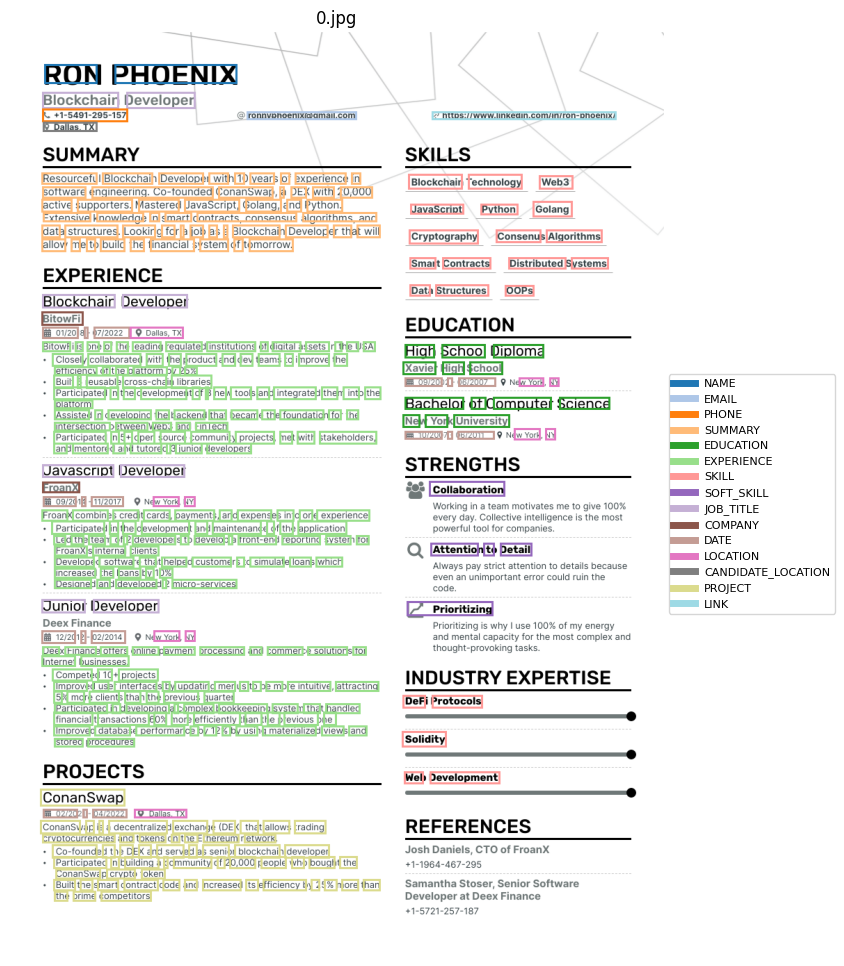

In [ ]:
# === PHASE A: kiểm tra trực quan matching trên 1 CV (tô màu theo entity) ===
from PIL import ImageDraw
import matplotlib.pyplot as plt

# màu riêng cho mỗi entity (để xem matching gán ĐÚNG nhãn chưa, không chỉ "có box")
_base = plt.get_cmap("tab20")
PALETTE = {e: tuple(int(255 * c) for c in _base(i / max(len(ENTITIES) - 1, 1))[:3])
           for i, e in enumerate(ENTITIES)}

def visualize(ex):
    img = Image.open(os.path.join(IMAGES_DIR, ex["image_file"])).convert("RGB"); W, H = img.size
    draw = ImageDraw.Draw(img)
    used = set()
    for box, tid in zip(ex["boxes"], ex["ner_tags"]):
        tag = id2label[tid]
        if tag == "O":
            continue
        ent = tag[2:]; used.add(ent)
        draw.rectangle([box[0]/1000*W, box[1]/1000*H, box[2]/1000*W, box[3]/1000*H],
                       outline=PALETTE.get(ent, (255, 0, 0)), width=3)
    plt.figure(figsize=(9, 12)); plt.imshow(img); plt.axis("off"); plt.title(ex["image_file"])
    handles = [plt.Line2D([0], [0], color=[c/255 for c in PALETTE[e]], lw=5)
               for e in ENTITIES if e in used]
    plt.legend(handles, [e for e in ENTITIES if e in used],
               loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
    plt.show()

visualize(examples[0])


In [ ]:
# === PHASE A: chọn 200 CV nét nhất CHƯA label + OCR sẵn pool (lưu ra Drive) ===
labeled_set = set(ls_regions.keys())
IMG_EXT = (".png", ".jpg", ".jpeg", ".webp")
candidates = [f for f in os.listdir(IMAGES_DIR)
              if f.lower().endswith(IMG_EXT) and f not in labeled_set]
print("Ảnh chưa label:", len(candidates))

def sharpness(path):
    img = cv2.imread(path)
    if img is None:  # webp / định dạng cv2 không đọc được -> dùng PIL
        img = cv2.cvtColor(np.array(Image.open(path).convert("RGB")), cv2.COLOR_RGB2BGR)
    return float(cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.CV_64F).var())

scored = []
for f in tqdm(candidates, desc="sharpness"):
    try:
        scored.append((f, sharpness(os.path.join(IMAGES_DIR, f))))
    except Exception:
        pass
scored.sort(key=lambda x: -x[1])
TOP_K = 200
pool = [f for f, _ in scored[:TOP_K]]
print("Đã chọn", len(pool), "ảnh nét nhất")

if os.path.exists(POOL_CACHE):
    pool_ocr = json.load(open(POOL_CACHE))
    print("Đã có cache pool:", len(pool_ocr), "CV")
else:
    pool_ocr = {}
    for f in tqdm(pool, desc="OCR pool"):
        wb = run_ocr_words(os.path.join(IMAGES_DIR, f))
        pool_ocr[f] = {"words": [w for w, _ in wb], "boxes_px": [b for _, b in wb]}
    json.dump(pool_ocr, open(POOL_CACHE, "w"))
    print("OCR pool xong:", len(pool_ocr), "CV ->", POOL_CACHE)


Ảnh chưa label: 1907


sharpness:   0%|          | 0/1907 [00:00<?, ?it/s]

Đã chọn 200 ảnh nét nhất
Đã có cache pool: 200 CV


✅ **Xong PHASE A.** Data đã lưu trên Drive (`train_examples.json`, `al_pool_ocr.json`).

Bây giờ:
1. **Runtime → Change runtime type → T4 GPU** → **Connect**.
2. **Chạy lại 2 cell mục SETUP** (mount Drive + nhãn) — đổi runtime sẽ reset bộ nhớ.
3. Bỏ qua PHASE A, chạy tiếp từ **PHASE B** bên dưới.


---
## 🅱️ PHASE B — GPU T4: train LayoutLMv3 + active learning
Đảm bảo đã đổi runtime sang **T4 GPU** và **đã chạy lại 2 cell SETUP**.


In [ ]:
# === PHASE B: cài thư viện train (KHÔNG cần PaddleOCR) ===
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "CHƯA có GPU - Runtime > Change runtime type > T4 GPU")
!pip -q install -U "transformers>=4.41" datasets evaluate seqeval accelerate
print("Cài xong PHASE B.")


GPU: Tesla T4
Cài xong PHASE B.


In [ ]:
# === PHASE B: nạp data đã chuẩn bị ở PHASE A ===
assert os.path.exists(TRAIN_CACHE), "Thiếu train_examples.json -> chạy PHASE A trước!"
assert os.path.exists(POOL_CACHE),  "Thiếu al_pool_ocr.json -> chạy PHASE A trước!"
examples = json.load(open(TRAIN_CACHE))
pool_ocr = json.load(open(POOL_CACHE))
print("Train examples:", len(examples), "| Pool active learning:", len(pool_ocr))


Train examples: 222 | Pool active learning: 200


In [ ]:
# === PHASE B: tạo Dataset + chia train/val (VAL CỐ ĐỊNH để so sánh được giữa các vòng) ===
from datasets import Dataset

VAL_CACHE = f"{OUTPUT_DIR}/val_files.json"

# Chốt tập validation 1 LẦN (vòng đầu) rồi lưu ra Drive. Các vòng sau dùng lại đúng tập đó
# -> F1 đo trên cùng 1 thước đo => so sánh được model có cải thiện hay không.
if os.path.exists(VAL_CACHE):
    val_files = set(json.load(open(VAL_CACHE)))
    print("Dùng lại VAL cố định:", len(val_files), "CV")
else:
    random.seed(42)
    names = sorted(ex["image_file"] for ex in examples)  # sort trước -> tái lập được
    random.shuffle(names)
    n_val = max(1, int(0.15 * len(names)))
    val_files = set(names[:n_val])
    json.dump(sorted(val_files), open(VAL_CACHE, "w"))
    print("Đã CỐ ĐỊNH val lần đầu:", len(val_files), "CV ->", VAL_CACHE)

# CV mới ở các vòng sau (không thuộc val_files) sẽ TỰ ĐỘNG vào tập train
val_examples   = [ex for ex in examples if ex["image_file"] in val_files]
train_examples = [ex for ex in examples if ex["image_file"] not in val_files]
train_ds = Dataset.from_list(train_examples)
val_ds   = Dataset.from_list(val_examples)
print("Train:", len(train_ds), "| Val (cố định):", len(val_ds))


Dùng lại VAL cố định: 24 CV
Train: 198 | Val (cố định): 24


In [ ]:
# === PHASE B: Processor LayoutLMv3 + encode (align nhãn theo subword, -100 cho subword sau) ===
from transformers import AutoProcessor
from datasets import Features, Sequence, Value, Array2D, Array3D

processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

def encode(batch):
    images = [Image.open(os.path.join(IMAGES_DIR, f)).convert("RGB") for f in batch["image_file"]]
    enc = processor(images, batch["words"], boxes=batch["boxes"],
                    word_labels=batch["ner_tags"],
                    truncation=True, padding="max_length", max_length=512)

    # Chuyển đổi mọi dạng tensor (ngay cả khi nằm trong list) thành Python list thuần
    res = {}
    for k, v in enc.items():
        if isinstance(v, list):
            res[k] = [(x.numpy().tolist() if hasattr(x, "numpy") else x) for x in v]
        elif hasattr(v, "numpy"):
            res[k] = v.numpy().tolist()
        else:
            res[k] = v
    return res

features = Features({
    "input_ids": Sequence(Value("int64")),
    "attention_mask": Sequence(Value("int64")),
    "bbox": Array2D(dtype="int64", shape=(512, 4)),
    "pixel_values": Array3D(dtype="float32", shape=(3, 224, 224)),
    "labels": Sequence(Value("int64")),
})
train_enc = train_ds.map(encode, batched=True, batch_size=4,
                         remove_columns=train_ds.column_names, features=features)
val_enc = val_ds.map(encode, batched=True, batch_size=4,
                     remove_columns=val_ds.column_names, features=features)
train_enc.set_format("torch"); val_enc.set_format("torch")
print(train_enc)

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'bbox', 'pixel_values', 'labels'],
    num_rows: 198
})


In [ ]:
# === PHASE B: Model + metric (seqeval) + Trainer ===
import numpy as np, evaluate
from transformers import (AutoModelForTokenClassification, TrainingArguments,
                          Trainer, default_data_collator)

model = AutoModelForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base", num_labels=num_labels,
    id2label=id2label, label2id=label2id)

seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    logits, labs = p
    preds = np.argmax(logits, axis=2)
    tp = [[id2label[a] for a, b in zip(pr, la) if b != -100] for pr, la in zip(preds, labs)]
    tl = [[id2label[b] for a, b in zip(pr, la) if b != -100] for pr, la in zip(preds, labs)]
    r = seqeval.compute(predictions=tp, references=tl, zero_division=0)
    return {"precision": r["overall_precision"], "recall": r["overall_recall"],
            "f1": r["overall_f1"], "accuracy": r["overall_accuracy"]}

args = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/checkpoints",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    num_train_epochs=30,
    eval_strategy="epoch",        # transformers < 4.41 dùng: evaluation_strategy
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    logging_steps=20,
    report_to="none",
)

trainer = Trainer(model=model, args=args, train_dataset=train_enc, eval_dataset=val_enc,
                  data_collator=default_data_collator, compute_metrics=compute_metrics)
trainer.train()


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.bias      | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,9.052077,1.587653,0.349127,0.129870,0.189317,0.559740
2,6.527247,1.208318,0.297602,0.195733,0.236150,0.676964
3,4.874431,0.937464,0.419187,0.372913,0.394698,0.762590
4,3.704599,0.744320,0.469697,0.460111,0.464855,0.796022
5,3.054511,0.639536,0.492641,0.527829,0.509628,0.834391
6,2.549638,0.548194,0.619526,0.629870,0.624655,0.850190
7,2.355610,0.482387,0.630638,0.687384,0.657790,0.870645
8,1.709090,0.489950,0.646025,0.716141,0.679278,0.880096
9,1.438670,0.476100,0.699729,0.719852,0.709648,0.881507
10,1.292907,0.369915,0.747331,0.779221,0.762943,0.906193


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=750, training_loss=1.4171904573440552, metrics={'train_runtime': 1177.9355, 'train_samples_per_second': 5.043, 'train_steps_per_second': 0.637, 'total_flos': 1577013646602240.0, 'train_loss': 1.4171904573440552, 'epoch': 30.0})

In [ ]:
# === PHASE B: đánh giá theo từng entity + lưu model + ghi lịch sử F1 qua các vòng ===
import pandas as pd, csv
out = trainer.predict(val_enc)
preds = np.argmax(out.predictions, axis=2); labs = out.label_ids
tp = [[id2label[a] for a, b in zip(pr, la) if b != -100] for pr, la in zip(preds, labs)]
tl = [[id2label[b] for a, b in zip(pr, la) if b != -100] for pr, la in zip(preds, labs)]
report = seqeval.compute(predictions=tp, references=tl, zero_division=0)
print("Overall  P/R/F1: %.3f / %.3f / %.3f" %
      (report["overall_precision"], report["overall_recall"], report["overall_f1"]))
rows = [{"entity": k, **v} for k, v in report.items() if isinstance(v, dict)]
display(pd.DataFrame(rows).sort_values("number", ascending=False).reset_index(drop=True))

MODEL_DIR = f"{OUTPUT_DIR}/model"
trainer.save_model(MODEL_DIR); processor.save_pretrained(MODEL_DIR)
print("Đã lưu model vào", MODEL_DIR)

# Lịch sử F1 qua các vòng (val cố định nên các dòng SO SÁNH ĐƯỢC với nhau)
hist_path = f"{OUTPUT_DIR}/metrics_history.csv"
is_new = not os.path.exists(hist_path)
with open(hist_path, "a", newline="") as fcsv:
    w = csv.writer(fcsv)
    if is_new:
        w.writerow(["n_train", "n_val", "precision", "recall", "f1"])
    w.writerow([len(train_examples), len(val_examples),
                round(report["overall_precision"], 4),
                round(report["overall_recall"], 4),
                round(report["overall_f1"], 4)])
print("Lịch sử F1 (mỗi dòng = 1 vòng retrain):")
display(pd.read_csv(hist_path))


Overall  P/R/F1: 0.818 / 0.842 / 0.830


,entity,precision,recall,f1,number
0,EXPERIENCE,0.829787,0.838710,0.834225,279
1,SKILL,0.698690,0.792079,0.742459,202
2,DATE,0.886364,0.906977,0.896552,86
3,JOB_TITLE,0.864198,0.909091,0.886076,77
4,SUMMARY,1.000000,1.000000,1.000000,72
5,EDUCATION,0.727273,0.786885,0.755906,61
6,COMPANY,0.844828,0.907407,0.875000,54
7,SOFT_SKILL,0.760000,0.745098,0.752475,51
8,LOCATION,0.730769,0.760000,0.745098,50
9,CERTIFICATION,0.619048,0.541667,0.577778,24


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu model vào /content/drive/MyDrive/DATN/layoutlmv3_out/model
Lịch sử F1 (mỗi dòng = 1 vòng retrain):


,n_train,n_val,precision,recall,f1
0,189,33,0.8001,0.8411,0.8201
1,138,24,0.8070,0.8571,0.8313
2,198,24,0.8180,0.8423,0.8300


In [ ]:
# === PHASE B: active learning - model dự đoán pool (OCR đã có sẵn) + tính độ bất định ===
import torch, torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device); model.eval()

LOW_CONF = 0.70  # ngưỡng coi 1 token là "không chắc"

def predict_doc(fname):
    img = Image.open(os.path.join(IMAGES_DIR, fname)).convert("RGB"); W, H = img.size
    words, boxes_px = pool_ocr[fname]["words"], pool_ocr[fname]["boxes_px"]
    if not words:
        return None
    boxes = [normalize_box(b, W, H) for b in boxes_px]
    enc = processor(img, words, boxes=boxes, truncation=True,
                    padding="max_length", max_length=512, return_tensors="pt")
    word_ids = enc.word_ids(0)
    with torch.no_grad():
        logits = model(**{k: v.to(device) for k, v in enc.items()}).logits[0]
    probs = F.softmax(logits, dim=-1).cpu()
    seen, per_word, confs, ents = set(), [], [], []
    for i, wid in enumerate(word_ids):
        if wid is None or wid in seen:
            continue
        seen.add(wid)
        p = probs[i]
        maxp = float(p.max())
        per_word.append((wid, int(p.argmax()), maxp))
        confs.append(maxp)
        ents.append(float(-(p * torch.log(p + 1e-9)).sum()))
    if not confs:
        return None
    u = {"mean_entropy": float(np.mean(ents)),
         "least_conf": 1.0 - float(np.mean(confs)),
         "low_frac": float(np.mean([c < LOW_CONF for c in confs])),
         "n_words": len(confs)}
    return {"file": fname, "W": W, "H": H, "boxes_px": boxes_px, "per_word": per_word, "u": u}

preds = [r for r in (predict_doc(f) for f in tqdm(pool_ocr)) if r]
preds.sort(key=lambda r: -r["u"]["mean_entropy"])

import pandas as pd
df = pd.DataFrame([{"file": r["file"], **r["u"]} for r in preds])
N_REVIEW = 60  # số CV bất định nhất gửi lại để bạn gán tay
df["need_review"] = False
df.loc[df.index[:N_REVIEW], "need_review"] = True
df.to_csv(f"{OUTPUT_DIR}/active_learning_report.csv", index=False)
print("Báo cáo:", f"{OUTPUT_DIR}/active_learning_report.csv")
display(df.head(20))


  0%|          | 0/200 [00:00<?, ?it/s]

Báo cáo: /content/drive/MyDrive/DATN/layoutlmv3_out/active_learning_report.csv


,file,mean_entropy,least_conf,low_frac,n_words,need_review
0,533.png,0.378924,0.162895,0.325581,258,True
1,527.png,0.378924,0.162895,0.325581,258,True
2,656.jpg,0.274256,0.076837,0.103774,106,True
3,50.jpg,0.252792,0.064163,0.066667,330,True
4,875.jpg,0.233305,0.060684,0.071429,280,True
5,851.png,0.206495,0.055759,0.062092,306,True
6,15.jpg,0.182221,0.043340,0.047297,296,True
7,658.jpg,0.178337,0.054898,0.086331,278,True
8,1874.png,0.177921,0.027001,0.000000,240,True
9,2012.png,0.163423,0.045529,0.061972,355,True


In [ ]:
# === PHASE B: xuất CV bất định -> file import Label Studio (kèm pre-annotation) ===
def decode_regions(r):
    # Gộp token cùng entity liền kề (theo BIO) thành 1 region
    regions, cur = [], None
    for wid, lab_id, conf in r["per_word"]:
        lab = id2label[lab_id]; box = r["boxes_px"][wid]
        if lab == "O":
            if cur: regions.append(cur); cur = None
            continue
        ent, bio = lab[2:], lab[:1]
        if bio == "B" or cur is None or cur["label"] != ent:
            if cur: regions.append(cur)
            cur = {"label": ent, "box": list(box)}
        else:
            cur["box"][0] = min(cur["box"][0], box[0]); cur["box"][1] = min(cur["box"][1], box[1])
            cur["box"][2] = max(cur["box"][2], box[2]); cur["box"][3] = max(cur["box"][3], box[3])
    if cur: regions.append(cur)
    return regions

def to_ls_results(regions, W, H):
    res = []
    for g in regions:
        x1, y1, x2, y2 = g["box"]
        res.append({"type": "rectanglelabels", "from_name": "label", "to_name": "image",
            "original_width": W, "original_height": H, "image_rotation": 0,
            "value": {"x": x1 / W * 100, "y": y1 / H * 100,
                      "width": (x2 - x1) / W * 100, "height": (y2 - y1) / H * 100,
                      "rotation": 0, "rectanglelabels": [g["label"]]}})
    return res

need = set(df[df["need_review"]]["file"])
ls_import, auto_labeled = [], []
for r in preds:
    res = to_ls_results(decode_regions(r), r["W"], r["H"])
    task = {"data": {"image": f"/data/local-files/?d=dataset_new/{r['file']}"},
            "predictions": [{"model_version": "layoutlmv3_al", "result": res}]}
    (ls_import if r["file"] in need else auto_labeled).append(task)

json.dump(ls_import, open(f"{OUTPUT_DIR}/label_studio_uncertain_import.json", "w"), ensure_ascii=False)
json.dump(auto_labeled, open(f"{OUTPUT_DIR}/auto_labeled.json", "w"), ensure_ascii=False)
print("Cần bạn gán tay (import vào Label Studio):", len(ls_import))
print("Auto-label (tin cậy cao):", len(auto_labeled))
print("File import:", f"{OUTPUT_DIR}/label_studio_uncertain_import.json")


Cần bạn gán tay (import vào Label Studio): 60
Auto-label (tin cậy cao): 140
File import: /content/drive/MyDrive/DATN/layoutlmv3_out/label_studio_uncertain_import.json


## Vòng lặp cải thiện model (retrain)

**Mỗi vòng train lại TỪ ĐẦU** (load lại `microsoft/layoutlmv3-base`, không tiếp tục từ checkpoint cũ) trên **toàn bộ data tích luỹ** = data ban đầu **+** các CV model thấy "không chắc" mà bạn vừa sửa nhãn. Đây là cách ổn định nhất cho data nhỏ.

1. Tải `label_studio_uncertain_import.json`, **Import** vào Label Studio (đã có sẵn box do model gợi ý), sửa cho đúng.
2. **Export** ra file JSON mới, up lên Drive.
3. Thêm đường dẫn file mới vào list **`LS_EXPORTS`** ở cell SETUP (giữ cả các file cũ).
4. Chạy lại **PHASE A**: nhờ **cache tăng dần**, chỉ OCR thêm các CV mới (không OCR lại các CV cũ) → đổi **T4** chạy **PHASE B**.
5. Lặp đến khi F1 đủ tốt thì dừng.

> - Nếu bạn **sửa nhãn của CV đã có sẵn** (không phải thêm CV mới), hãy **xoá `train_examples.json`** để OCR + match lại từ đầu — cache không tự bắt thay đổi đó.
> - `auto_labeled.json` (CV model rất tự tin) **không** tự được đưa vào train. Muốn dùng làm pseudo-label thì trộn thêm thủ công, nhưng nên ưu tiên data bạn đã kiểm tay.


## Bước tiếp theo (notebook riêng): Gợi ý CV ↔ JD

Sau khi có model LayoutLMv3 ổn:
1. Dùng model parse CV → các field có cấu trúc (SKILL, EXPERIENCE, EDUCATION, ...).
2. **Crawl JD** từ các trang tuyển dụng để tạo dữ liệu.
3. Tạo feature cho cặp (CV, JD): độ trùng skill, số năm kinh nghiệm, học vấn, ...
4. Train **SVM / Random Forest** dự đoán mức độ match.
5. Sinh gợi ý theo template, ví dụ:
   > *CV của bạn match JD này **x%**. Bạn mạnh ở **A, B**. Cần cải thiện **C, D, E** để tăng tỉ lệ đậu.*


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Số word OCR: 281
['NGUYEN', 'TRONG', 'TRI', 'Intern', 'Full-stack', 'Developer', '0344904181nguyentrongtri.hcmus@gmail.com', 'https://github.com/trongtriGH', 'Ho', 'Chi', 'Minh', 'City', 'OBJECTIVES', 'Enthusiastic', 'and', 'fast-learning', 'Full', 'Stack', 'Developer', 'Intern', 'with', 'a', 'solid', 'understanding', 'of', 'web', 'development', 'fundamentals,', 'including', 'Ul/UX,', 'APls,', 'and', 'database', 'management.', 'Looking', 'to', 'gain', 'practical', 'experience,contribute', 'to', 'meaningful', 'projects,', 'and', 'grow', 'into', 'a', 'professional', 'software', 'engineer.', 'EDUCATION']


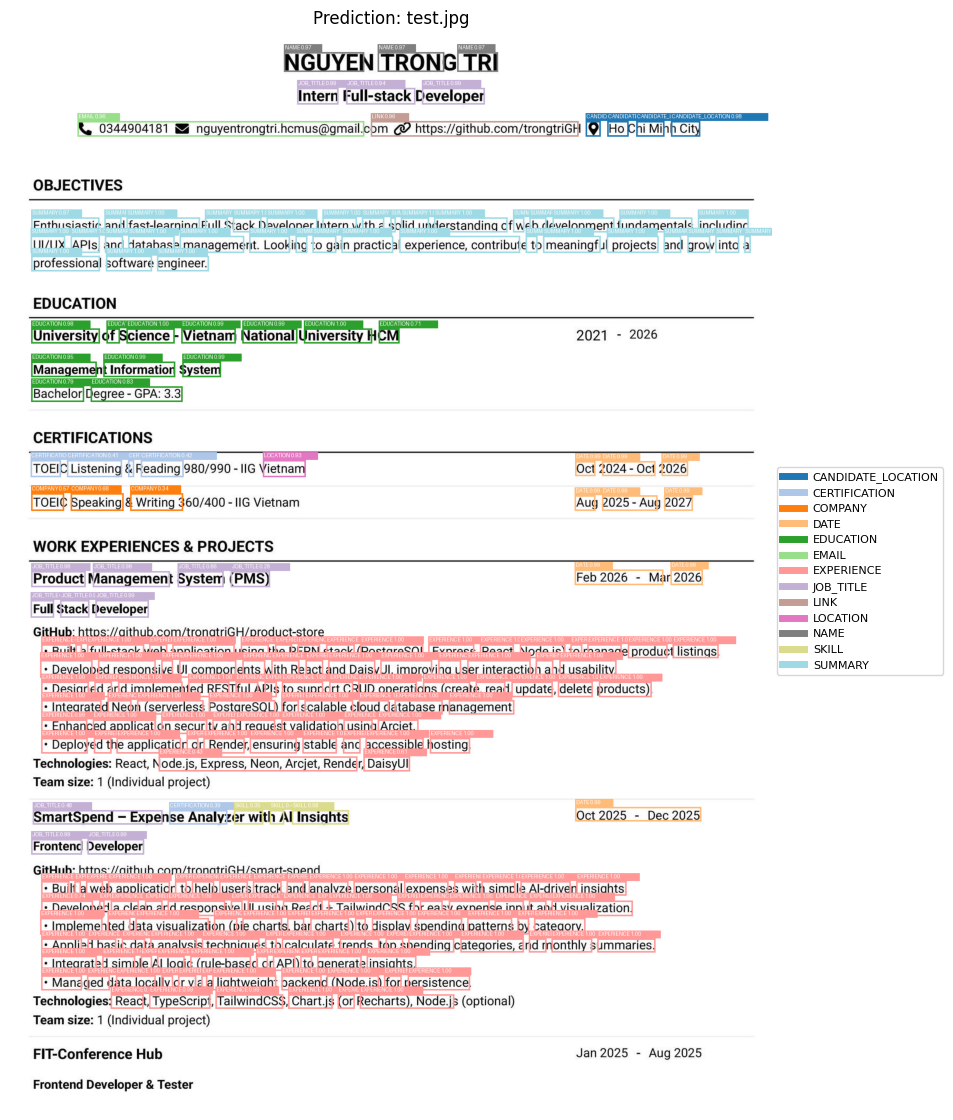

,word,box,pred_label,score
0,NGUYEN,"[360, 19, 465, 37]",B-NAME,0.973751
1,TRONG,"[483, 19, 570, 37]",I-NAME,0.968528
2,TRI,"[587, 19, 640, 37]",I-NAME,0.966228
3,Intern,"[377, 52, 431, 67]",B-JOB_TITLE,0.989639
4,Full-stack,"[441, 52, 532, 67]",I-JOB_TITLE,0.940701
...,...,...,...,...
212,visualization.,"[711, 806, 817, 820]",I-EXPERIENCE,0.999283
213,Implemented,"[40, 822, 121, 837]",I-EXPERIENCE,0.998997
214,data,"[128, 822, 158, 837]",I-EXPERIENCE,0.999295
215,visualization,"[165, 822, 261, 837]",I-EXPERIENCE,0.999305


In [ ]:
# === OCR 1 IMAGE bằng PaddleOCR -> Predict LayoutLMv3 -> Vẽ box ===
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
from transformers import AutoProcessor, LayoutLMv3ForTokenClassification

# ===== chỉnh 2 dòng này =====
MODEL_DIR = "/content/drive/MyDrive/DATN/layoutlmv3_out/model"
IMAGE_PATH = "/content/drive/MyDrive/DATN/dataset/dataset_new/test.jpg"
# ============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load OCR giống phase train
ocr_engine = PaddleOCR(
    use_angle_cls=True,
    lang="en",
    show_log=False,
    use_gpu=False
)

# Load model đã train
processor = AutoProcessor.from_pretrained(MODEL_DIR, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

id2label = model.config.id2label


def quad_to_aabb(quad):
    xs = [float(p[0]) for p in quad]
    ys = [float(p[1]) for p in quad]
    return [min(xs), min(ys), max(xs), max(ys)]


def split_line_to_words(text, box):
    """
    PaddleOCR trả box theo dòng.
    Hàm này chia box dòng thành box từng từ theo tỷ lệ số ký tự.
    Giống cách bạn dùng khi train.
    """
    x1, y1, x2, y2 = box
    words = text.split()

    if not words:
        return []

    total = max(
        sum(len(w) for w in words) + max(len(words) - 1, 0),
        1
    )

    out = []
    cur = x1
    span = x2 - x1

    for w in words:
        wx2 = cur + (len(w) / total) * span
        out.append((w, [cur, y1, wx2, y2]))
        cur = wx2 + (1.0 / total) * span

    return out


def normalize_box(box, W, H):
    """
    Convert box pixel -> box 0-1000 cho LayoutLM.
    """
    x1, y1, x2, y2 = box

    # tránh box bị đảo
    x1, x2 = sorted([x1, x2])
    y1, y2 = sorted([y1, y2])

    def n(v, m):
        return min(1000, max(0, int(round(1000.0 * v / max(m, 1)))))

    return [
        n(x1, W),
        n(y1, H),
        n(x2, W),
        n(y2, H),
    ]


def run_ocr_words(img_path):
    """
    OCR 1 ảnh -> list (word, box_pixel)
    """
    res = ocr_engine.ocr(img_path, cls=True)
    lines = res[0] if (res and res[0]) else []

    words = []

    for item in lines:
        quad, (text, conf) = item[0], item[1]

        if not text or not text.strip():
            continue

        line_box = quad_to_aabb(quad)
        words.extend(split_line_to_words(text.strip(), line_box))

    return words


# ===== OCR ảnh =====
img = Image.open(IMAGE_PATH).convert("RGB")
W, H = img.size

ocr_words = run_ocr_words(IMAGE_PATH)

if not ocr_words:
    raise ValueError("OCR không đọc được word nào từ ảnh này.")

words = []
boxes = []

for w, pixel_box in ocr_words:
    words.append(w)
    boxes.append(normalize_box(pixel_box, W, H))

print("Số word OCR:", len(words))
print(words[:50])


# ===== Encode + predict =====
encoding = processor(
    images=img,
    text=words,
    boxes=boxes,
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)

word_ids = encoding.word_ids(batch_index=0)

inputs = {
    k: v.to(device)
    for k, v in encoding.items()
    if isinstance(v, torch.Tensor)
}

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits[0]
probs = torch.softmax(logits, dim=-1)

pred_ids = torch.argmax(probs, dim=-1).cpu().numpy()
scores = torch.max(probs, dim=-1).values.cpu().numpy()


# ===== Màu entity =====
ENTITIES = sorted({
    label[2:]
    for label in id2label.values()
    if label != "O" and label.startswith(("B-", "I-"))
})

_base = plt.get_cmap("tab20")
PALETTE = {
    e: tuple(int(255 * c) for c in _base(i / max(len(ENTITIES) - 1, 1))[:3])
    for i, e in enumerate(ENTITIES)
}


def box_1000_to_pixel(box, W, H):
    x1, y1, x2, y2 = box
    return [
        int(x1 / 1000 * W),
        int(y1 / 1000 * H),
        int(x2 / 1000 * W),
        int(y2 / 1000 * H),
    ]


# ===== Vẽ box dự đoán =====
draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("DejaVuSans.ttf", 13)
except:
    font = None

rows = []
seen = set()
used = set()

CONF_TH = 0.0   # đổi 0.5 hoặc 0.6 nếu muốn lọc box tự tin cao hơn

for token_idx, word_id in enumerate(word_ids):
    if word_id is None:
        continue

    # chỉ lấy subword đầu tiên của mỗi word
    if word_id in seen:
        continue

    seen.add(word_id)

    if word_id >= len(words):
        continue

    pred_id = int(pred_ids[token_idx])
    score = float(scores[token_idx])
    label = id2label[pred_id]

    if score < CONF_TH:
        label = "O"

    word = words[word_id]
    box = boxes[word_id]

    rows.append({
        "word": word,
        "box": box,
        "pred_label": label,
        "score": score,
    })

    if label == "O":
        continue

    entity = label[2:]
    used.add(entity)

    color = PALETTE.get(entity, (255, 0, 0))
    x1, y1, x2, y2 = box_1000_to_pixel(box, W, H)

    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

    text = f"{entity} {score:.2f}"
    ty = max(0, y1 - 15)

    draw.rectangle(
        [x1, ty, x1 + len(text) * 8, ty + 14],
        fill=color
    )
    draw.text(
        (x1 + 2, ty),
        text,
        fill=(255, 255, 255),
        font=font
    )


# ===== Hiển thị ảnh =====
plt.figure(figsize=(10, 14))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {os.path.basename(IMAGE_PATH)}")

handles = [
    plt.Line2D([0], [0], color=[c / 255 for c in PALETTE[e]], lw=5)
    for e in ENTITIES
    if e in used
]

labels_used = [e for e in ENTITIES if e in used]

if handles:
    plt.legend(
        handles,
        labels_used,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=8
    )

plt.show()


# ===== Bảng dự đoán =====
df_pred = pd.DataFrame(rows)

display(df_pred[df_pred["pred_label"] != "O"].head(200))